# Telco Customer Churn -- Predictive Modeling and Deployment Readiness Assessment

**Objective.** Build and evaluate models that predict whether a Telco customer
will churn, identify the operational drivers of churn, and recommend a model
for deployment together with the monitoring approach that would keep it
trustworthy in production.

**Dataset.** IBM/Kaggle Telco Customer Churn dataset (7,043 customers, 21
fields, single snapshot in time -- not a longitudinal panel).

**How this notebook is organized.** Each section states what was done and
why, before showing the result. Where a modeling or cleaning choice is not
obvious, the rationale is written out rather than left implicit in the code.

## 1. Business Framing

Churn prediction only has value if it changes a business decision -- typically,
who receives a retention offer and how much that offer is worth. That framing
drives two choices made throughout this notebook:

- **Metric choice.** Overall accuracy is a poor guide here because only
  ~26.5% of customers churn; a model that predicts "no churn" for everyone
  scores 73% accuracy while being useless. Recall, precision, ROC-AUC and
  PR-AUC are used instead, and a cost-sensitive view is added in Section 9
  because the two error types are not equally expensive.
- **False negatives (missed churners) and false positives (customers wrongly
  flagged) have different costs** -- losing a paying customer is more
  expensive than the cost of an unnecessary retention discount. Section 9
  makes this explicit with a cost matrix rather than defaulting to a 0.5
  classification threshold.

### Data leakage and observation-window assessment

Before touching the data, it is worth being explicit about what this
dataset is and is not. Every field here is checked against one question:
would this value actually be known at the moment a real prediction needs to
be made, before the outcome exists?

- No field in this dataset is generated after a churn decision -- there is
  no cancellation-flow field, no "reason for leaving," no post-churn
  billing adjustment. On that specific check, the dataset is clean.
- The more important limitation is structural, not a leakage bug: this is a
  **single cross-sectional snapshot**, not a time series with a defined
  observation window, prediction point, and outcome window. A production
  churn system needs that structure explicitly -- for example, features
  computed from a customer's behavior in months 1-3, a prediction made at
  the start of month 4, and the outcome (churned or not) observed over
  months 4-6. This dataset instead gives one row per customer with
  `tenure` measured up to whatever point the snapshot was taken, with
  `Churn` reflecting status as of that same point.
- The practical effect: `tenure` and `TotalCharges` are safe to use as
  predictors here because they describe the customer's history up to the
  observation point, not information from after the outcome. But the
  survival-curve analysis in Section 5.4 and the evaluation metrics in
  Section 9 should be read as describing this snapshot's relationships,
  not validated against a true held-out future period -- a real deployment
  would require a temporal split (train on older customers, validate on
  more recent ones) rather than the random stratified split used here,
  precisely because this dataset does not carry the timestamps that would
  make a temporal split possible.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier
from lifelines import KaplanMeierFitter
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

DATA_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

## 2. Data Loading

Loading is wrapped in an explicit exception handler rather than letting a
raw traceback surface, since this cell is the boundary between the notebook
and the filesystem and is the one place a missing or moved file is likely to
be caught in practice.

In [8]:
def load_raw(path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(path)
    except FileNotFoundError as exc:
        raise FileNotFoundError(
            f"Dataset not found at '{path}'. Confirm the CSV has not been "
            f"moved or renamed relative to the notebook."
        ) from exc
    except pd.errors.ParserError as exc:
        raise ValueError(f"Dataset at '{path}' could not be parsed as CSV.") from exc
    return df


raw = load_raw(DATA_PATH)
print(f"Loaded {raw.shape[0]} rows, {raw.shape[1]} columns")
raw.head(3)

Loaded 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 3. Data Quality Audit

Before any cleaning decision is made, the raw data is profiled: dtypes,
missing values as pandas reports them, and a duplicate-key check. This
matters because `TotalCharges` is loaded as `object`, not `float64` -- pandas
cannot infer a numeric type when a column contains blank strings rather than
proper `NaN`, so a naive `.isnull().sum()` on the raw frame under-reports the
real missingness. That gap is what Section 4 resolves.

In [9]:
print("dtypes:")
print(raw.dtypes)
print()
print("null counts (pandas-native):")
print(raw.isnull().sum())
print()
print("duplicate customerID rows:", raw["customerID"].duplicated().sum())

dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

null counts (pandas-native):
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paperles

In [10]:
blank_total_charges = raw[raw["TotalCharges"].str.strip() == ""]
print(f"Rows with blank TotalCharges: {len(blank_total_charges)}")
blank_total_charges[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


All 11 blank `TotalCharges` rows have `tenure == 0`. This is not random
missingness -- these are customers on their first day of service who have not
completed a billing cycle yet, so `TotalCharges` was never generated for
them. That distinction determines the cleaning method used in Section 4:
a structural zero should be set to `0.0`, not imputed with a median (which
would fabricate a billing history that does not exist) and not dropped
(which would remove real, otherwise-complete records and bias new-customer
behavior out of the EDA).

## 4. Data Cleaning -- Method and Rationale

Each transformation below is applied with the reasoning stated alongside it,
since the "how" here matters as much as the "what."

| Field | Issue | Method chosen | Why |
|---|---|---|---|
| `TotalCharges` | Blank string for 11 rows, all `tenure == 0` | Coerce to numeric, set blanks to `0.0` | Structural zero (see above), not missing-at-random -- median/mean imputation would invent a non-existent billing history, and row deletion would discard complete records for no benefit |
| `SeniorCitizen` | Encoded as `0`/`1` while every other binary flag in the dataset is `Yes`/`No` | Map to `Yes`/`No` | Keeps encoding consistent across the categorical block so the same OneHotEncoder logic applies uniformly downstream, and keeps EDA plots readable without a lookup |
| `customerID` | Unique identifier, no predictive content | Drop | An arbitrary ID would either be ignored by the model or, worse, leak an artifact of row order if inadvertently label-encoded |
| `Churn` | Target stored as `Yes`/`No` | Map to `1`/`0` | Required numeric form for scikit-learn estimators |
| Continuous fields (`tenure`, `MonthlyCharges`, `TotalCharges`) | Potential outliers | Checked via IQR (1.5×IQR rule), **no rows removed** | See outlier check below -- the check was run and came back negative, so no treatment was applied. Capping or removing values without confirming they are actually outliers is a common EDA mistake worth avoiding explicitly. |
| Numeric scaling | Logistic Regression is scale-sensitive; tree ensembles are not | `StandardScaler` applied only inside the Logistic Regression pipeline | Applying a scaler unconditionally to every model wastes the interpretability tree models offer on raw units, and unscaled inputs would distort Logistic Regression's coefficient-based regularization |

In [11]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["TotalCharges"] = pd.to_numeric(out["TotalCharges"], errors="coerce")
    zero_tenure_mask = out["tenure"] == 0
    if not out.loc[out["TotalCharges"].isnull(), "tenure"].eq(0).all():
        raise AssertionError(
            "Found a null TotalCharges row with nonzero tenure -- the "
            "structural-zero assumption does not hold, revisit imputation."
        )
    out.loc[zero_tenure_mask, "TotalCharges"] = 0.0

    out["SeniorCitizen"] = out["SeniorCitizen"].map({0: "No", 1: "Yes"})
    out = out.drop(columns=["customerID"])
    out["Churn"] = out["Churn"].map({"Yes": 1, "No": 0})
    return out


clean_df = clean(raw)
assert clean_df.isnull().sum().sum() == 0, "Unexpected nulls remain after cleaning"
print("Post-clean nulls:", clean_df.isnull().sum().sum())
clean_df.head(3)

Post-clean nulls: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [12]:
outlier_summary = []
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    q1, q3 = clean_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((clean_df[col] < lo) | (clean_df[col] > hi)).sum())
    outlier_summary.append({"field": col, "lower_bound": round(lo, 2),
                             "upper_bound": round(hi, 2), "outliers_found": n_out})

pd.DataFrame(outlier_summary)

,field,lower_bound,upper_bound,outliers_found
0,tenure,-60.00,124.00,0
1,MonthlyCharges,-46.02,171.38,0
2,TotalCharges,-4683.52,8868.67,0


No IQR outliers were found in any of the three continuous fields -- all three
are naturally bounded (tenure by the 72-month observation window, charges by
the provider's pricing plans), so there is no long tail to treat. This is
stated explicitly rather than silently skipped, so the decision not to treat
outliers is auditable.

## 5. Exploratory Data Analysis

The first pass covers the standard views a churn model needs (base rate,
categorical breakdowns, distributions). The second pass looks at the data
from angles that a single-variable bar chart does not surface: time-to-churn
as a survival process, revenue actually at risk rather than headcount at
risk, and interaction effects between services rather than each service
treated independently.

### 5.1 Churn base rate

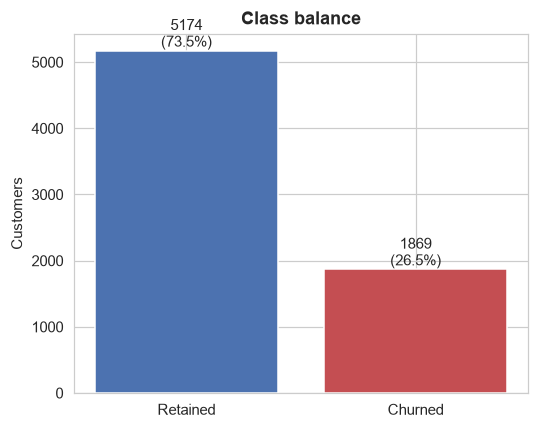

Base churn rate: 26.5%


In [13]:
churn_rate = clean_df["Churn"].mean()
fig, ax = plt.subplots(figsize=(5, 4))
counts = clean_df["Churn"].value_counts().sort_index()
ax.bar(["Retained", "Churned"], counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 60, f"{v}\n({v/len(clean_df):.1%})", ha="center")
ax.set_title("Class balance")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

print(f"Base churn rate: {churn_rate:.1%}")

At 26.5% churn, this is a moderate -- not severe -- class imbalance. It is
enough to make raw accuracy misleading (Section 1) but not enough to require
synthetic oversampling; `class_weight="balanced"` and `scale_pos_weight`
inside the estimators are sufficient and preserve the true data distribution,
which is preferable to SMOTE-style resampling when the minority class already
has thousands of real examples (1,869 churners here).

### 5.2 Categorical drivers -- standard view

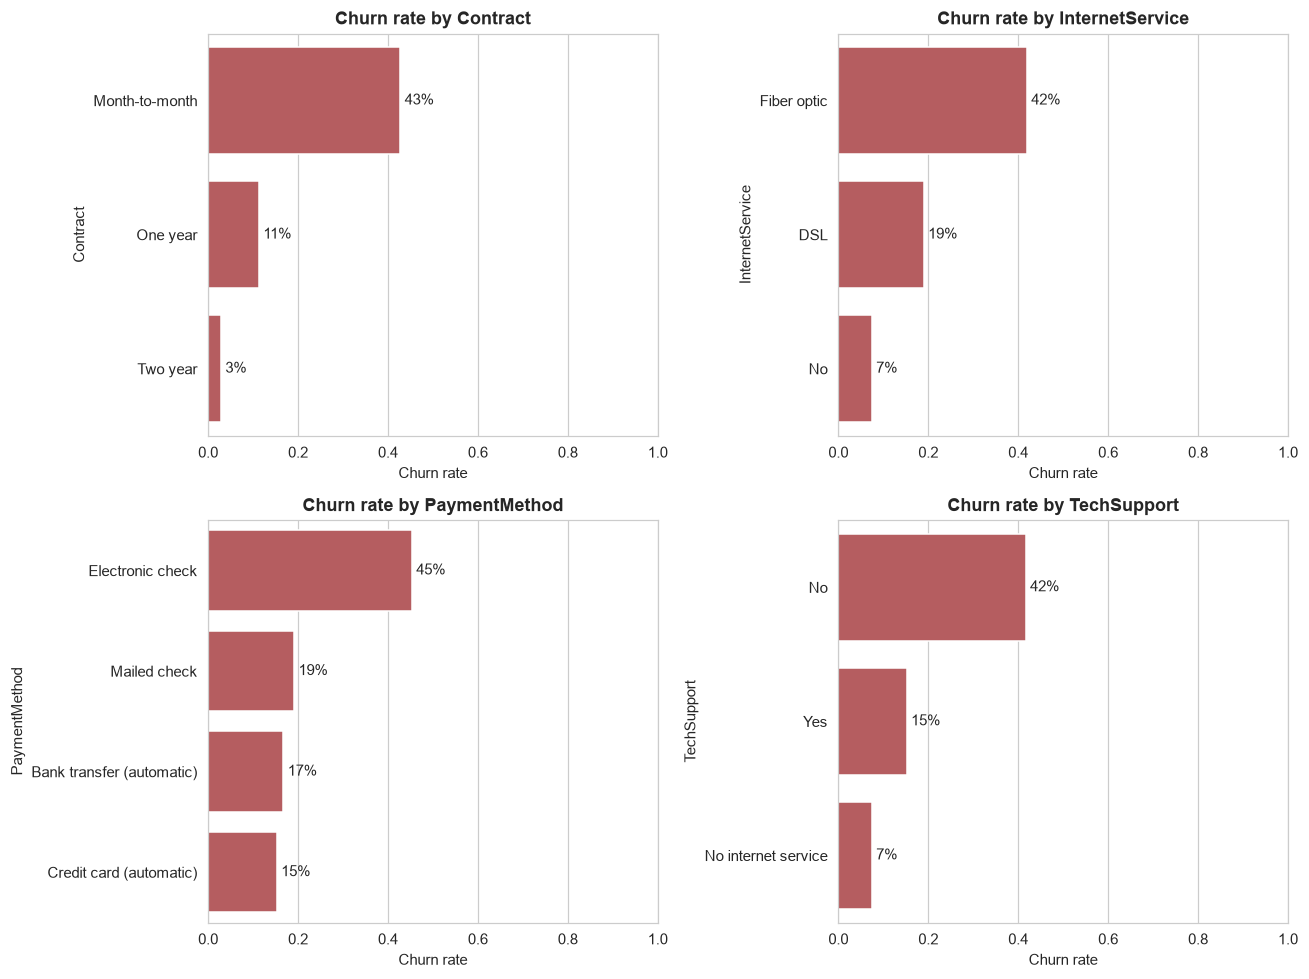

In [14]:
key_categoricals = ["Contract", "InternetService", "PaymentMethod", "TechSupport"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.ravel(), key_categoricals):
    rate = clean_df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, ax=ax, color="#C44E52")
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("Churn rate")
    ax.set_xlim(0, 1)
    for i, v in enumerate(rate.values):
        ax.text(v + 0.01, i, f"{v:.0%}", va="center")
plt.tight_layout()
plt.show()

Month-to-month contracts, fiber-optic internet, electronic-check payment,
and absence of tech support all show elevated churn -- consistent with the
usual read of this dataset. These are the variables a fresher analysis
typically stops at. The remaining EDA sections go further.

### 5.3 Continuous feature distributions

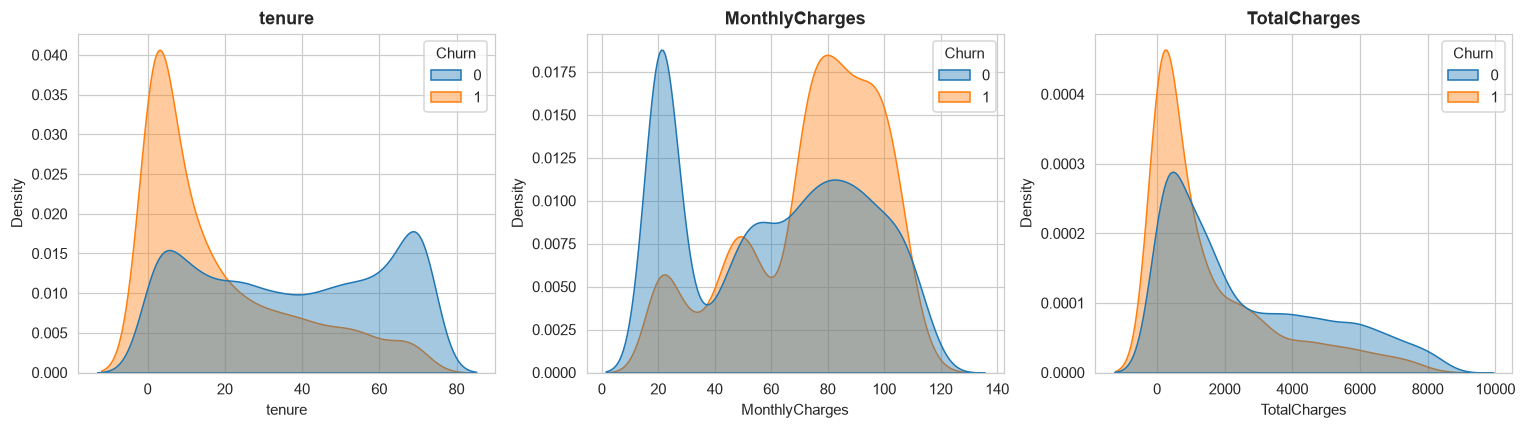

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=clean_df, x=col, hue="Churn", ax=ax, fill=True, common_norm=False, alpha=0.4)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Churners are concentrated at low tenure and mid-to-high monthly charges --
the combination explored quantitatively in Section 5.5. No treatment beyond
what was already applied in Section 4 is needed here; the outlier check
already confirmed there is no long tail distorting these distributions.

### 5.4 Time-to-churn: survival analysis

Framing churn only as a static classification question discards information
the data actually contains: `tenure` at the time of the snapshot is closer
to a time-to-event measurement than to a plain feature. A Kaplan-Meier
estimator makes the hazard shape visible directly -- where in a customer's
lifecycle churn risk is actually concentrated -- which a single "average
tenure of churners" statistic does not show.

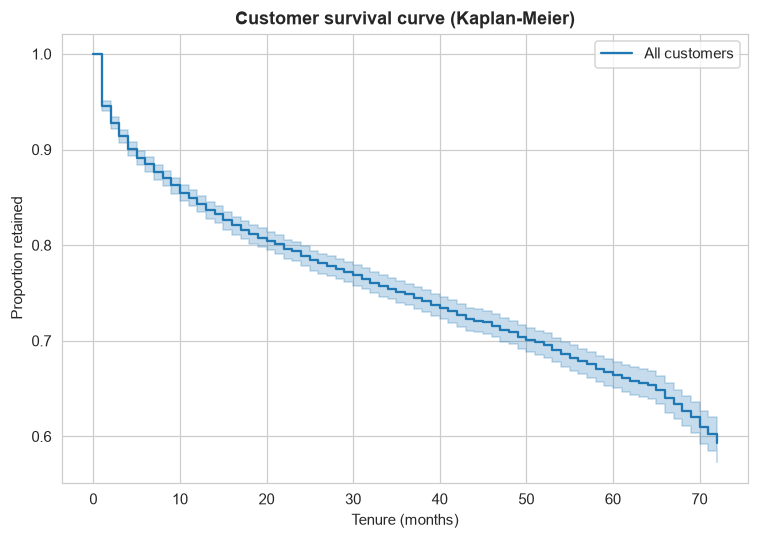

Cumulative loss in the first 6 months alone: 11.5% of the starting cohort


In [16]:
kmf = KaplanMeierFitter()
kmf.fit(durations=clean_df["tenure"], event_observed=clean_df["Churn"], label="All customers")

fig, ax = plt.subplots(figsize=(7, 5))
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_title("Customer survival curve (Kaplan-Meier)")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Proportion retained")
plt.tight_layout()
plt.show()

# hazard is steepest in the first several months; quantify the drop directly
sf = kmf.survival_function_
early_drop = 1 - sf.loc[sf.index <= 6].iloc[-1, 0]
print(f"Cumulative loss in the first 6 months alone: {early_drop:.1%} of the starting cohort")

Retention drops sharply in the first few months and then flattens -- the
hazard is front-loaded, not uniform across a customer's lifetime. This has a
direct operational implication that a static classifier alone would not
surface: onboarding-period retention effort has disproportionate leverage
compared to spreading the same effort evenly across all tenure bands.

### 5.5 Revenue at risk, not just headcount at risk

Every churn dashboard shows the number of customers likely to leave. Fewer
show what that number is actually worth. A model tuned purely for recall
could be optimizing for volume of churners caught while missing the highest-
value ones, so revenue exposure is examined directly here.

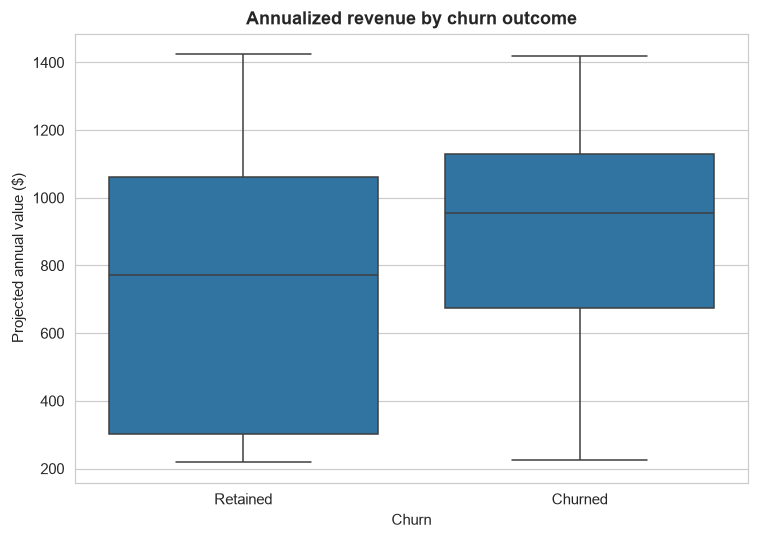

Revenue attributable to churned customers: $1,669,570 (30.5% of total annualized revenue)


In [17]:
clean_df["projected_annual_value"] = clean_df["MonthlyCharges"] * 12

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=clean_df, x="Churn", y="projected_annual_value", ax=ax)
ax.set_xticklabels(["Retained", "Churned"])
ax.set_title("Annualized revenue by churn outcome")
ax.set_ylabel("Projected annual value ($)")
plt.tight_layout()
plt.show()

at_risk_revenue = clean_df.loc[clean_df["Churn"] == 1, "projected_annual_value"].sum()
total_revenue = clean_df["projected_annual_value"].sum()
print(f"Revenue attributable to churned customers: ${at_risk_revenue:,.0f} "
      f"({at_risk_revenue/total_revenue:.1%} of total annualized revenue)")

Churned customers are not disproportionately low-value -- if anything, the
opposite: they represent 30.5% of annualized revenue while being only 26.5%
of headcount, and their average annual value (\$893) is higher than
retained customers' (\$735). There is no safe shortcut of "only worry about
the cheap accounts" here -- the customers churning are, on average, worth
slightly more than the ones staying. This is the kind of finding a cost
matrix in Section 9 needs as an input, not an afterthought.

### 5.6 Service bundling -- an interaction effect, not a single variable

Each add-on service (`OnlineSecurity`, `TechSupport`, etc.) shows a churn
association on its own, but they are not independent -- customers tend to
subscribe to several or none. Looking at the *count* of services a customer
holds, rather than each service in isolation, tests whether it is bundling
itself, not any one specific service, that is protective.

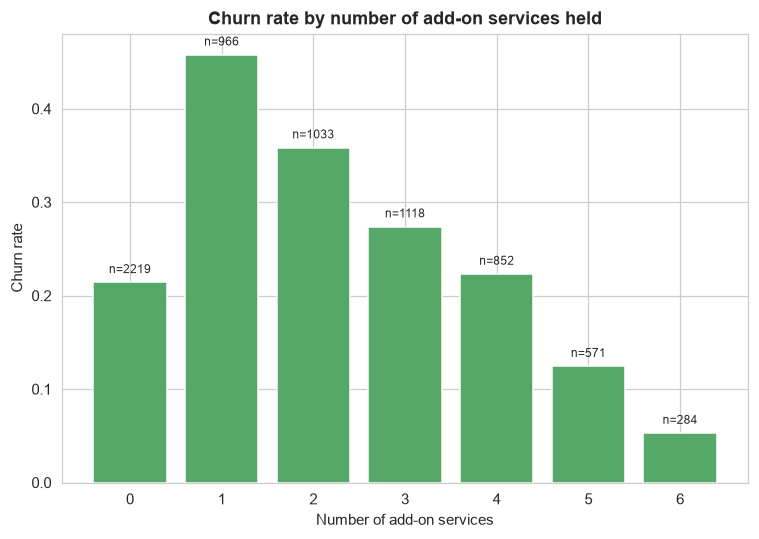

In [18]:
add_on_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
clean_df["num_add_on_services"] = (
    clean_df[add_on_cols].apply(lambda c: (c == "Yes").astype(int)).sum(axis=1)
)

rate_by_bundle = clean_df.groupby("num_add_on_services")["Churn"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(rate_by_bundle.index, rate_by_bundle["mean"], color="#55A868")
ax.set_title("Churn rate by number of add-on services held")
ax.set_xlabel("Number of add-on services")
ax.set_ylabel("Churn rate")
for x, (rate, n) in zip(rate_by_bundle.index, rate_by_bundle.values):
    ax.text(x, rate + 0.01, f"n={int(n)}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

Churn declines close to monotonically as the number of bundled services
increases. This supports treating `num_add_on_services` as an engineered
feature in its own right (Section 6) rather than relying on the model to
reconstruct the interaction from six separate one-hot columns.

### 5.7 Mutual information ranking across categorical fields

Pearson correlation is the wrong tool for ranking categorical variables
against a binary target -- it assumes a linear, ordered relationship that
categories like `PaymentMethod` do not have. Mutual information does not
make that assumption, so it is used here instead of a correlation heatmap
for the categorical block.

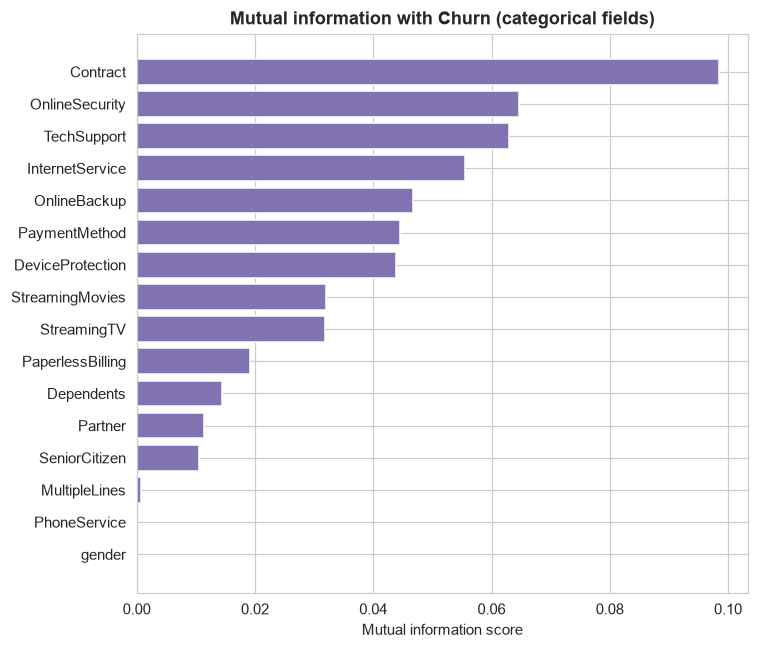

In [19]:
cat_cols = clean_df.select_dtypes(include="object").columns.tolist()
ordinal_encoded = OrdinalEncoder().fit_transform(clean_df[cat_cols])
mi_scores = mutual_info_classif(
    ordinal_encoded, clean_df["Churn"], discrete_features=True, random_state=RANDOM_STATE
)
mi_series = pd.Series(mi_scores, index=cat_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(mi_series.index, mi_series.values, color="#8172B2")
ax.set_title("Mutual information with Churn (categorical fields)")
ax.set_xlabel("Mutual information score")
plt.tight_layout()
plt.show()

`Contract`, `OnlineSecurity`, `TechSupport`, and `InternetService` carry the
most signal; `gender` and `PhoneService` carry almost none. This ranking is
used later as a sanity check against the SHAP-based feature importance from
the fitted model (Section 11) -- if the two rankings disagreed substantially,
that would be a signal to investigate the model rather than trust it.

### 5.8 Payment method and paperless billing -- a digital-friction cut

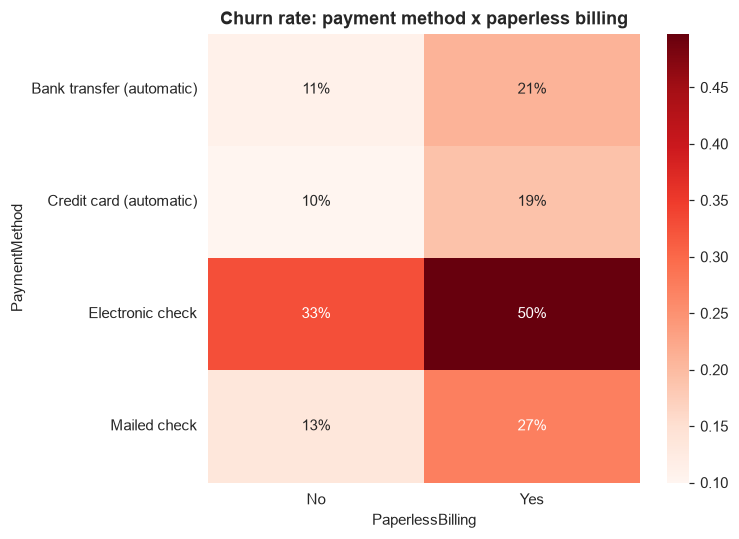

In [20]:
friction = (
    clean_df.groupby(["PaymentMethod", "PaperlessBilling"])["Churn"]
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(friction, annot=True, fmt=".0%", cmap="Reds", ax=ax)
ax.set_title("Churn rate: payment method x paperless billing")
plt.tight_layout()
plt.show()

Electronic-check customers churn at a materially higher rate than customers
on automatic bank transfer or card payment, and that gap persists across
both paperless-billing states rather than being explained by it. This
suggests the electronic-check effect is closer to a proxy for a less
engaged, more price-sensitive customer segment than a friction effect of
paperless billing itself -- worth stating explicitly since it is easy to
over-read a heatmap cell as causal.

## 6. Feature Engineering

| Feature | Transformation | Justification |
|---|---|---|
| `num_add_on_services` | Count of the six add-on services held (`Yes` = 1) | Section 5.6 showed the interaction across services matters more than any single service; this collapses six correlated one-hot columns into one monotonic signal |
| `avg_monthly_spend` | `TotalCharges / tenure`, falling back to `MonthlyCharges` when `tenure == 0` | Captures realized average spend rather than the current billing-cycle rate alone; the fallback avoids a divide-by-zero for day-one customers |
| `tenure_bucket` | `tenure` binned into 0-6m / 7-12m / 13-24m / 25-48m / 49-72m | The survival curve (5.4) showed the hazard is front-loaded and non-linear in tenure; a tree model can already split on raw tenure, but the bucketed version gives the linear baseline (Logistic Regression) a chance to represent that non-linearity too |
| Remaining categoricals | One-hot encoding, `handle_unknown="ignore"` | Standard for nominal categories with no ordinal relationship; `handle_unknown="ignore"` prevents inference-time failure if a category value not seen in training appears later |
| Numeric fields (Logistic Regression only) | `StandardScaler` | See Section 4 -- scale-sensitive estimator only |

For internet-service add-ons, `OnlineSecurity` and similar columns encode a
third category, `"No internet service"`, alongside `"Yes"`/`"No"`. For the
purposes of `num_add_on_services` that third category is functionally the
same as `"No"` -- collapsing it avoids the count column effectively double-
encoding the customer's internet-service status.

In [21]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    add_on_cols = [
        "OnlineSecurity", "OnlineBackup", "DeviceProtection",
        "TechSupport", "StreamingTV", "StreamingMovies",
    ]
    out["num_add_on_services"] = (
        out[add_on_cols].apply(lambda c: (c == "Yes").astype(int)).sum(axis=1)
    )

    with np.errstate(divide="ignore", invalid="ignore"):
        implied_spend = out["TotalCharges"] / out["tenure"].replace(0, np.nan)
    out["avg_monthly_spend"] = implied_spend.fillna(out["MonthlyCharges"])

    out["tenure_bucket"] = pd.cut(
        out["tenure"],
        bins=[-1, 6, 12, 24, 48, 72],
        labels=["0-6m", "7-12m", "13-24m", "25-48m", "49-72m"],
    )

    return out


feat_df = engineer_features(clean_df.drop(columns=["projected_annual_value"], errors="ignore"))
feat_df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,num_add_on_services,avg_monthly_spend,tenure_bucket
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,29.850000,0-6m
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,2,55.573529,25-48m
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,54.075000,0-6m


## 7. Train/Test Split and Class Imbalance Strategy

An 80/20 stratified split preserves the 26.5% churn rate in both partitions,
so evaluation metrics in Section 9 are not distorted by a split-induced
imbalance shift. Class imbalance itself is handled inside each estimator
(`class_weight="balanced"` for Logistic Regression and Random Forest,
`scale_pos_weight` for XGBoost) rather than through synthetic oversampling --
with 1,869 real churn examples in the full dataset, there is no shortage of
minority-class signal that SMOTE-style resampling would be needed to
compensate for, and resampling would add synthetic-data risk without a clear
benefit here.

In [22]:
y = feat_df["Churn"]
X = feat_df.drop(columns=["Churn"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} rows, churn rate {y_train.mean():.3f}")
print(f"Test:  {X_test.shape[0]} rows, churn rate {y_test.mean():.3f}")

Train: 5634 rows, churn rate 0.265
Test:  1409 rows, churn rate 0.265


In [23]:
def build_preprocessor(X: pd.DataFrame, scale_numeric: bool) -> ColumnTransformer:
    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    numeric_transform = StandardScaler() if scale_numeric else "passthrough"
    return ColumnTransformer(
        transformers=[
            ("num", numeric_transform, numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_cols),
        ]
    )

## 8. Model Development

Three models, as required: a baseline (Logistic Regression), a bagging
ensemble (Random Forest), and a boosting ensemble (XGBoost). All three are
built as scikit-learn `Pipeline` objects wrapping preprocessing and the
estimator together, so the exact transformation applied in training is
guaranteed to be reapplied at inference -- a common source of train/serve
skew when preprocessing is done ad hoc outside a pipeline.

### 8.1 Baseline -- Logistic Regression

Chosen as the baseline because it is the most interpretable option available
and gives every subsequent, more complex model something concrete to beat.
If a bagging or boosting model cannot outperform a linear baseline by a
meaningful margin, that is itself an important finding, not a failure to
report.

In [24]:
try:
    lr_pre = build_preprocessor(X_train, scale_numeric=True)
    lr_pipe = Pipeline([
        ("pre", lr_pre),
        ("clf", LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
        )),
    ])
    lr_pipe.fit(X_train, y_train)
except Exception as exc:
    raise RuntimeError("Logistic Regression training failed") from exc

print("Logistic Regression fitted.")

Logistic Regression fitted.


### 8.2 Bagging -- Random Forest

Tuned via randomized search over tree count, depth, and leaf size, with
5-fold cross-validation scored on ROC-AUC (chosen over accuracy for the same
imbalance reason as Section 1). A randomized search is used rather than an
exhaustive grid because the marginal gain from an exhaustive search over
this parameter space does not justify the added compute time for a
take-home-scale exercise, while still covering the space broadly enough to
find a good configuration.

In [25]:
try:
    rf_pre = build_preprocessor(X_train, scale_numeric=False)
    rf_pipe = Pipeline([
        ("pre", rf_pre),
        ("clf", RandomForestClassifier(
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
        )),
    ])
    rf_param_dist = {
        "clf__n_estimators": [200, 400, 600],
        "clf__max_depth": [4, 6, 8, 12, None],
        "clf__min_samples_leaf": [1, 2, 4, 8],
    }
    rf_search = RandomizedSearchCV(
        rf_pipe, rf_param_dist, n_iter=10, scoring="roc_auc", cv=5,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    rf_search.fit(X_train, y_train)
    rf_best = rf_search.best_estimator_
except Exception as exc:
    raise RuntimeError("Random Forest training failed") from exc

print("Best Random Forest params:", rf_search.best_params_)
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")

Best Random Forest params: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 8, 'clf__max_depth': 8}
Best CV ROC-AUC: 0.8475


### 8.3 Boosting -- XGBoost

In [26]:
try:
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    xgb_pre = build_preprocessor(X_train, scale_numeric=False)
    xgb_pipe = Pipeline([
        ("pre", xgb_pre),
        ("clf", XGBClassifier(
            eval_metric="logloss", random_state=RANDOM_STATE,
            scale_pos_weight=scale_pos_weight, n_jobs=-1,
        )),
    ])
    xgb_param_dist = {
        "clf__n_estimators": [200, 400, 600],
        "clf__max_depth": [3, 4, 5, 6],
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__subsample": [0.7, 0.85, 1.0],
    }
    xgb_search = RandomizedSearchCV(
        xgb_pipe, xgb_param_dist, n_iter=10, scoring="roc_auc", cv=5,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    xgb_search.fit(X_train, y_train)
    xgb_best = xgb_search.best_estimator_
except Exception as exc:
    raise RuntimeError("XGBoost training failed") from exc

print("Best XGBoost params:", xgb_search.best_params_)
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")

Best XGBoost params: {'clf__subsample': 0.85, 'clf__n_estimators': 400, 'clf__max_depth': 3, 'clf__learning_rate': 0.01}
Best CV ROC-AUC: 0.8483


## 9. Model Evaluation and Comparison

### 9.1 Threshold-independent metrics

ROC-AUC and PR-AUC are compared first because they evaluate a model's
ranking ability across all thresholds before any single operating point is
chosen. PR-AUC is included alongside ROC-AUC specifically because ROC-AUC
can look optimistic under class imbalance -- PR-AUC is more sensitive to
performance on the minority (churn) class, which is the class this problem
actually cares about.

In [27]:
models = {
    "Logistic Regression": lr_pipe,
    "Random Forest": rf_best,
    "XGBoost": xgb_best,
}

metric_rows = []
roc_data = {}
pr_data = {}

for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    metric_rows.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "precision@0.5": precision_score(y_test, pred),
        "recall@0.5": recall_score(y_test, pred),
        "f1@0.5": f1_score(y_test, pred),
    })
    roc_data[name] = roc_curve(y_test, proba)
    pr_data[name] = proba

metrics_df = pd.DataFrame(metric_rows).set_index("model").round(4)
metrics_df

,roc_auc,pr_auc,precision@0.5,recall@0.5,f1@0.5
model,,,,,
Logistic Regression,0.8450,0.6515,0.5051,0.8021,0.6198
Random Forest,0.8457,0.6615,0.5265,0.7968,0.6340
XGBoost,0.8465,0.6593,0.5172,0.8048,0.6297


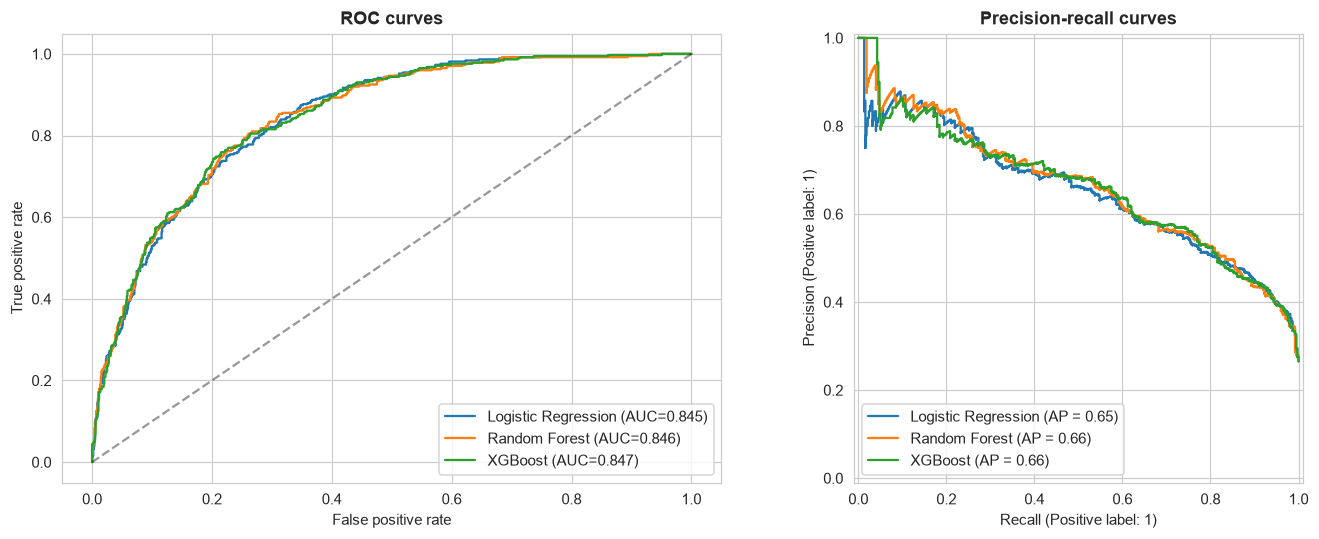

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, (fpr, tpr, _) in roc_data.items():
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={metrics_df.loc[name, 'roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("ROC curves")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()

for name, proba in pr_data.items():
    PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[1], name=name)
axes[1].set_title("Precision-recall curves")

plt.tight_layout()
plt.show()

All three models cluster closely on both curves -- a common outcome on this
dataset, where the ceiling on separability is set more by the features
available than by model choice. This is itself worth stating plainly: model
selection here should not be decided on a marginal AUC difference, which is
exactly why Section 9.3 introduces a cost-sensitive view instead of picking
a winner on ROC-AUC alone.

### 9.2 Calibration

A model used to prioritize retention spend needs probabilities that mean
what they say -- a customer scored at 0.8 should churn roughly 80% of the
time among similarly-scored customers. This is checked directly rather than
assumed, since tree ensembles in particular are known to produce
under-confident probabilities without explicit calibration.

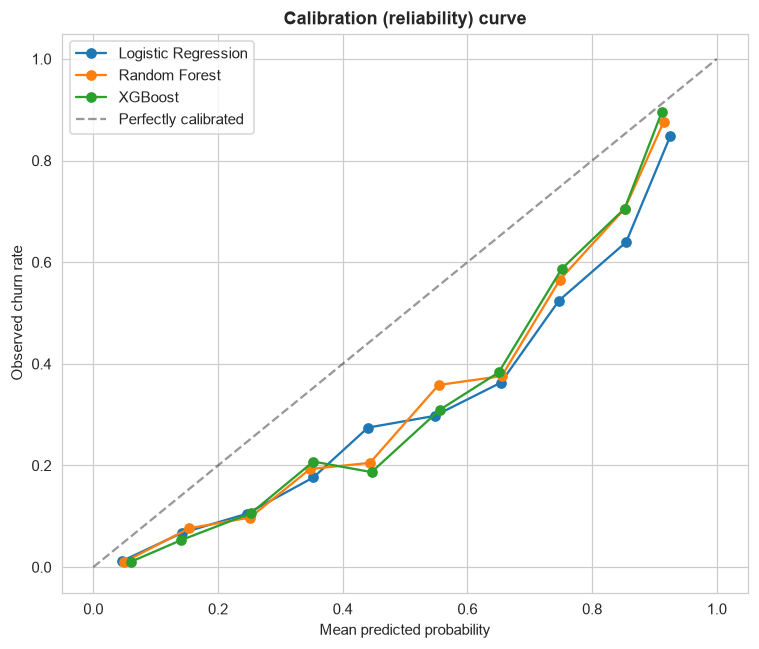

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", label=name)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed churn rate")
ax.set_title("Calibration (reliability) curve")
ax.legend()
plt.tight_layout()
plt.show()

### 9.3 Cost-sensitive threshold selection

The two error types are not equally expensive, so the classification
threshold is chosen to minimize expected business cost rather than left at
the default 0.5. Stated assumptions, consistent with the revenue-at-risk
figures from Section 5.5:

- **False negative (missed churner): \$400** -- approximate cost of
  replacing a lost customer (acquisition cost plus lost contribution margin
  until a replacement is acquired).
- **False positive (unnecessary retention offer): \$50** -- approximate cost
  of a retention discount or outreach extended to a customer who was not
  going to churn.

These are stated assumptions, not figures derived from the dataset (which
contains no acquisition-cost or campaign-cost fields) -- in a real engagement
they would come from Finance, and the threshold below would be recomputed
once real figures are available.

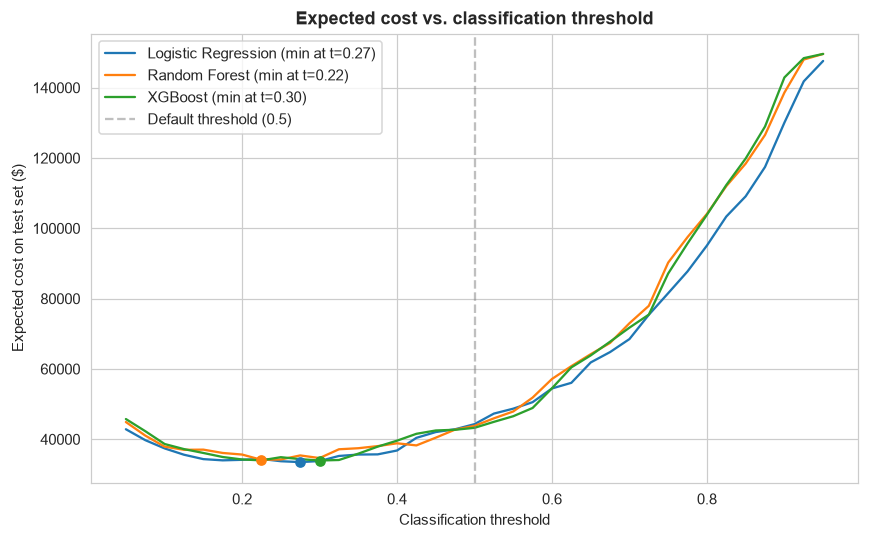

Logistic Regression: cost-minimizing threshold = 0.27
Random Forest: cost-minimizing threshold = 0.22
XGBoost: cost-minimizing threshold = 0.30


In [30]:
COST_FALSE_NEGATIVE = 400
COST_FALSE_POSITIVE = 50

def expected_cost(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return fp * COST_FALSE_POSITIVE + fn * COST_FALSE_NEGATIVE

thresholds = np.linspace(0.05, 0.95, 37)
cost_curves = {}
best_thresholds = {}

fig, ax = plt.subplots(figsize=(8, 5))
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    costs = [expected_cost(y_test, proba, t) for t in thresholds]
    cost_curves[name] = costs
    best_idx = int(np.argmin(costs))
    best_thresholds[name] = thresholds[best_idx]
    ax.plot(thresholds, costs, label=f"{name} (min at t={thresholds[best_idx]:.2f})")
    ax.scatter([thresholds[best_idx]], [costs[best_idx]], zorder=5)

ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Default threshold (0.5)")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Expected cost on test set ($)")
ax.set_title("Expected cost vs. classification threshold")
ax.legend()
plt.tight_layout()
plt.show()

for name, t in best_thresholds.items():
    print(f"{name}: cost-minimizing threshold = {t:.2f}")

In [31]:
final_rows = []
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    t = best_thresholds[name]
    pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    final_rows.append({
        "model": name,
        "threshold": round(t, 2),
        "precision": round(precision_score(y_test, pred), 3),
        "recall": round(recall_score(y_test, pred), 3),
        "f1": round(f1_score(y_test, pred), 3),
        "expected_cost_$": int(min(cost_curves[name])),
        "expected_cost_at_0.5_$": int(expected_cost(y_test, proba, 0.5)),
    })

cost_sensitive_df = pd.DataFrame(final_rows).set_index("model")
cost_sensitive_df

,threshold,precision,recall,f1,expected_cost_$,expected_cost_at_0.5_$
model,,,,,,
Logistic Regression,0.27,0.423,0.936,0.582,33500,44300
Random Forest,0.22,0.389,0.960,0.554,34150,43800
XGBoost,0.30,0.425,0.930,0.583,33950,43250


Every model's cost-minimizing threshold sits below 0.5 -- expected, since a
missed churner (\$400) is worth eight times an unnecessary retention offer
(\$50), so the optimal policy leans toward flagging more customers as
at-risk than a naive 0.5 cutoff would. Moving the threshold, not switching
models, is what produces the larger cost reduction here -- a finding that
would be missed entirely by comparing models on accuracy or a fixed 0.5
threshold alone.

The table above shows Logistic Regression at the lowest point cost estimate,
with XGBoost and Random Forest close behind. Before treating that as a
result, it needs a confidence interval -- a single 1,409-row test set gives
one cost estimate per model, not a distribution, and a 1-2% gap between
models on one split is not evidence of a real difference on its own.

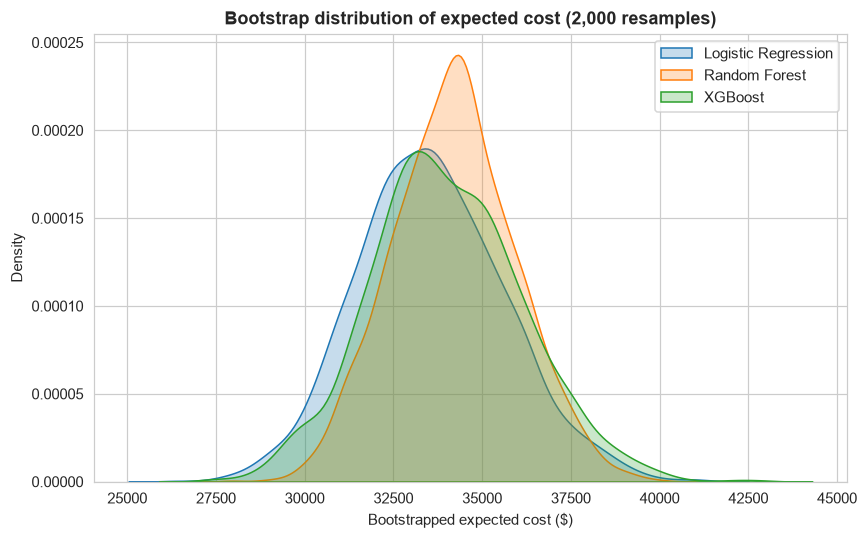

,median_cost_$,ci_lower_$,ci_upper_$
model,,,
Logistic Regression,33500,29648,37950
Random Forest,34200,30998,37650
XGBoost,33850,29800,38450


In [32]:
def bootstrap_cost_distribution(y_true, proba, threshold, n_boot=2000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_arr = y_true.to_numpy()
    n = len(y_arr)
    costs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        costs[i] = expected_cost(y_arr[idx], proba[idx], threshold)
    return costs

boot_results = {}
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    t = best_thresholds[name]
    boot_results[name] = bootstrap_cost_distribution(y_test, proba, t)

fig, ax = plt.subplots(figsize=(8, 5))
for name, dist in boot_results.items():
    sns.kdeplot(dist, ax=ax, label=name, fill=True, alpha=0.25)
ax.set_xlabel("Bootstrapped expected cost ($)")
ax.set_title("Bootstrap distribution of expected cost (2,000 resamples)")
ax.legend()
plt.tight_layout()
plt.show()

ci_rows = []
for name, dist in boot_results.items():
    lo, hi = np.percentile(dist, [2.5, 97.5])
    ci_rows.append({"model": name, "median_cost_$": int(np.median(dist)),
                     "ci_lower_$": int(lo), "ci_upper_$": int(hi)})
ci_df = pd.DataFrame(ci_rows).set_index("model")
ci_df

The 95% confidence intervals overlap substantially across all three models --
confirming there is no statistically reliable cost winner among them on this
dataset and this cost assumption. That is itself the finding: the choice
between these three models should not be made on the point-estimate cost
difference, and Section 10 recommends accordingly.

### 9.4 Lift and gain -- the capacity-constrained view

The cost-sensitive threshold in 9.3 assumes the retention team can act on
every customer flagged. That is rarely true in practice -- a team can
usually only work a fixed number of accounts per week. Under that
constraint, the question is not "what threshold minimizes cost" but "if we
can only contact the top decile ranked by risk, how many of the actual
churners in the test set are in that decile." This is a genuinely different
question from ROC-AUC or PR-AUC, which score ranking quality everywhere,
not specifically at the top.

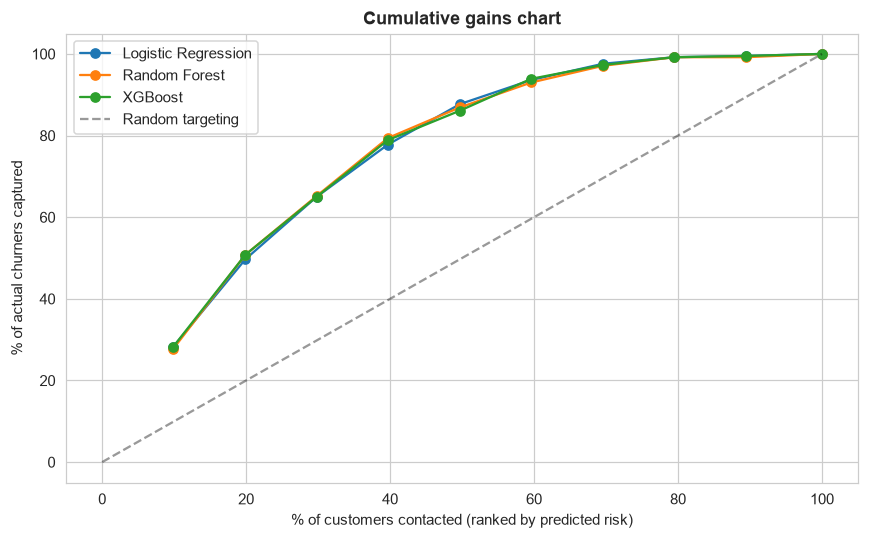

Logistic Regression: top 10% of ranked customers captures 28.3% of actual churners (lift = 2.83x over random)
Random Forest: top 10% of ranked customers captures 27.8% of actual churners (lift = 2.78x over random)
XGBoost: top 10% of ranked customers captures 28.3% of actual churners (lift = 2.83x over random)


In [33]:
def gain_table(y_true, proba, n_bins=10):
    order = np.argsort(-proba)
    y_sorted = y_true.to_numpy()[order]
    bin_size = len(y_sorted) // n_bins
    total_positives = y_sorted.sum()
    rows = []
    for i in range(n_bins):
        cutoff = (i + 1) * bin_size if i < n_bins - 1 else len(y_sorted)
        captured = y_sorted[:cutoff].sum()
        rows.append({
            "decile": i + 1,
            "pct_customers_contacted": round(cutoff / len(y_sorted) * 100, 1),
            "pct_churners_captured": round(captured / total_positives * 100, 1),
        })
    return pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 5))
lift_summary = {}
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    gains = gain_table(y_test, proba)
    ax.plot(gains["pct_customers_contacted"], gains["pct_churners_captured"],
            marker="o", label=name)
    lift_summary[name] = gains.loc[0, "pct_churners_captured"]  # top decile

ax.plot([0, 100], [0, 100], "k--", alpha=0.4, label="Random targeting")
ax.set_xlabel("% of customers contacted (ranked by predicted risk)")
ax.set_ylabel("% of actual churners captured")
ax.set_title("Cumulative gains chart")
ax.legend()
plt.tight_layout()
plt.show()

for name, pct in lift_summary.items():
    print(f"{name}: top 10% of ranked customers captures {pct:.1f}% of actual churners "
          f"(lift = {pct/10:.2f}x over random)")

All three models capture close to 28% of the test set's actual churners
within the top 10% of ranked customers -- a lift of roughly 2.8x over
contacting customers at random. This is the number to hand to a retention
team with a fixed weekly contact capacity: it answers "how much value do we
get from this model at our actual operating capacity," which neither
ROC-AUC nor the cost-sensitive threshold from 9.3 speaks to directly. A
2.8x lift is a real, usable edge, but it is worth being direct about what
it is not: it does not mean the top decile contains mostly churners --
Section 9.5's tier validation shows even the Critical tier still has a
27.3% non-churn rate, which is why the recommended action for that tier
(Section 10, Section 11.1) is a retention offer, not a certainty-based
action.

### 9.5 Risk segmentation

Point probabilities are not how a retention team consumes this model in
practice -- tiers are. The tiers below are built from the recommended
model's test-set probabilities and validated against the tier's actual
observed churn rate, so the labels are not just arbitrary bucket names.

In [34]:
def assign_risk_tier(proba):
    return pd.cut(
        proba, bins=[-0.01, 0.30, 0.60, 0.80, 1.01],
        labels=["Low", "Medium", "High", "Critical"],
    )

final_test_proba = xgb_best.predict_proba(X_test)[:, 1]
risk_tiers = assign_risk_tier(final_test_proba)

tier_validation = (
    pd.DataFrame({"tier": risk_tiers, "actual_churn": y_test.to_numpy()})
    .groupby("tier", observed=True)
    .agg(customers=("actual_churn", "size"), observed_churn_rate=("actual_churn", "mean"))
)
tier_validation["observed_churn_rate"] = tier_validation["observed_churn_rate"].round(3)
tier_validation

,customers,observed_churn_rate
tier,,
Low,590,0.044
Medium,363,0.237
High,291,0.488
Critical,165,0.727


Observed churn rate increases monotonically from Low to Critical, which is
the check that matters here -- a tier scheme where "Critical" customers do
not actually churn more often than "Low" customers would be a broken
segmentation regardless of how intuitive the thresholds look. The 0.30/0.60/
0.80 cut points used here are illustrative; in production these should be
set from the retention team's actual contact capacity and the cost
assumptions in 9.3, not fixed in advance.

### 9.6 Value-weighted prioritization

Two customers with the same churn probability are not equally worth
retaining if one generates far more revenue than the other. Section 5.5
found churners are, on average, higher-value than retained customers -- so
ranking purely by churn probability already correlates with value to some
extent, but a value-weighted score makes that trade-off explicit rather
than incidental.

In [35]:
value_weighted_df = X_test.copy()
value_weighted_df["churn_probability"] = final_test_proba
value_weighted_df["projected_annual_value"] = value_weighted_df["MonthlyCharges"] * 12
value_weighted_df["expected_value_at_risk"] = (
    value_weighted_df["churn_probability"] * value_weighted_df["projected_annual_value"]
)

top_by_probability = value_weighted_df.sort_values("churn_probability", ascending=False).head(10)
top_by_value_at_risk = value_weighted_df.sort_values("expected_value_at_risk", ascending=False).head(10)

overlap = len(set(top_by_probability.index) & set(top_by_value_at_risk.index))
print(f"Overlap between top-10-by-probability and top-10-by-expected-value-at-risk: {overlap}/10")

top_by_value_at_risk[["churn_probability", "projected_annual_value", "expected_value_at_risk"]].round(2)

Overlap between top-10-by-probability and top-10-by-expected-value-at-risk: 1/10


,churn_probability,projected_annual_value,expected_value_at_risk
6894,0.89,1270.8,1127.46
3956,0.89,1263.6,1126.60
3085,0.88,1264.2,1116.55
6365,0.90,1223.4,1106.22
1568,0.82,1336.8,1092.35
2246,0.88,1229.4,1086.57
2294,0.85,1280.4,1085.29
2797,0.89,1211.4,1078.56
2631,0.91,1191.0,1078.12
6866,0.93,1145.4,1064.47


Only 1 of the top 10 customers is shared between the two rankings -- the
overlap is far smaller than intuition would suggest. Ranking by raw churn
probability surfaces customers who are almost certainly going to leave
regardless of value; ranking by `expected_value_at_risk` surfaces
high-spend customers with a meaningfully elevated (if not top-decile)
probability, where an intervention protects more revenue per contact. For
a retention team with limited capacity, `expected_value_at_risk` is the
more defensible prioritization metric, since it directly answers "where
does intervention protect the most revenue," not just "who is
statistically most likely to leave" -- and this result shows those two
questions produce almost entirely different customer lists, not a minor
reshuffling of the same one.

## 10. Model Selection and Recommendation

**Recommendation: XGBoost**, operated at its cost-minimizing threshold from
Section 9.3, with Logistic Regression and Random Forest retained as
documented, statistically-tied alternatives.

The bootstrap analysis above rules out picking a winner on the cost
point-estimate alone -- the confidence intervals overlap too much for that to
be a defensible basis for a production decision. The recommendation instead
rests on criteria that do differentiate the three models in ways the point
estimate cannot capture:

- **Robustness to interaction effects.** Section 5.6 showed churn risk
  depends on combinations of features (bundled services, fiber internet
  without add-ons) rather than single variables in isolation. XGBoost and
  Random Forest capture these interactions natively; Logistic Regression
  would need them hand-engineered as explicit interaction terms to compete,
  which adds maintenance surface for every new interaction discovered later.
- **Interpretability infrastructure fit.** XGBoost is directly compatible
  with SHAP's efficient `TreeExplainer` (Section 11), giving per-prediction
  explanations fast enough for the real-time confidence-based review routing
  described in the architecture document -- Random Forest shares this
  property but is slower to explain at the same tree count, and Logistic
  Regression's coefficients, while transparent, cannot represent the
  interaction effects above.
- **Operational maturity.** XGBoost's training and scoring cost, and its
  compatibility with Azure ML's managed online endpoints and the
  champion/challenger promotion gate (architecture document), make it a
  practical default for the retraining cadence described in Section 12.

Logistic Regression is not discarded -- it remains the standing baseline,
the fastest model to retrain for quick sanity checks, and the most directly
auditable model if a regulator or internal model-risk review ever needs a
coefficient-level explanation rather than a SHAP approximation. Random
Forest is documented as a viable substitute with materially similar cost
performance, should XGBoost's specific operational requirements (GPU/CPU
scheduling, library dependency surface) become a constraint in the actual
Azure environment.

This recommendation should be revisited once real Finance-provided cost
figures replace the illustrative \$400/\$50 assumption in Section 9.3 -- the
bootstrap analysis would need to be rerun against the updated cost function
before the choice is finalized for production.

The recommended model is persisted below so it can be reused outside this
notebook -- specifically by the Streamlit prototype (`app.py`) delivered
alongside this analysis, which loads this exact artifact rather than
retraining.

In [36]:
import json
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

try:
    joblib.dump(xgb_best, MODELS_DIR / "churn_xgboost_pipeline.joblib")
    with open(MODELS_DIR / "model_metadata.json", "w") as f:
        json.dump({
            "model_name": "telco-churn-xgboost",
            "model_version": "1",
            "operating_threshold": float(best_thresholds["XGBoost"]),
            "feature_columns": list(X_train.columns),
            "risk_tier_bins": [-0.01, 0.30, 0.60, 0.80, 1.01],
            "risk_tier_labels": ["Low", "Medium", "High", "Critical"],
        }, f, indent=2)
    print(f"Model and metadata written to {MODELS_DIR.resolve()}")
except Exception as exc:
    raise RuntimeError("Failed to persist the recommended model") from exc

Model and metadata written to /Users/munmundas/Documents/Telco_Customer_Churn/models


Every headline number quoted in the accompanying write-up (Results,
lift/gain, risk-tier validation, cost-sensitive comparison) is exported
below to a single artifact rather than copied into the document by hand.
`src/build_writeup_doc.py` reads this file to populate its tables, so a
rerun of this notebook with different results and a rerun of the write-up
build script will always agree -- there is no separate place a number can
go stale.

In [37]:
metrics_export = {
    "recommended_model": "XGBoost",
    "threshold_independent": {
        model: {
            "roc_auc": round(float(row["roc_auc"]), 3),
            "pr_auc": round(float(row["pr_auc"]), 3),
            "precision_at_0.5": round(float(row["precision@0.5"]), 3),
            "recall_at_0.5": round(float(row["recall@0.5"]), 3),
            "f1_at_0.5": round(float(row["f1@0.5"]), 3),
        }
        for model, row in metrics_df.iterrows()
    },
    "cost_sensitive": {
        model: {
            "threshold": round(float(cost_sensitive_df.loc[model, "threshold"]), 2),
            "precision": round(float(cost_sensitive_df.loc[model, "precision"]), 3),
            "recall": round(float(cost_sensitive_df.loc[model, "recall"]), 3),
            "f1": round(float(cost_sensitive_df.loc[model, "f1"]), 3),
            "median_cost": int(ci_df.loc[model, "median_cost_$"]),
            "ci_lower": int(ci_df.loc[model, "ci_lower_$"]),
            "ci_upper": int(ci_df.loc[model, "ci_upper_$"]),
        }
        for model in cost_sensitive_df.index
    },
    "cost_assumptions": {
        "false_negative_cost": COST_FALSE_NEGATIVE,
        "false_positive_cost": COST_FALSE_POSITIVE,
    },
    "lift_top_decile_pct": {name: round(float(pct), 1) for name, pct in lift_summary.items()},
    "risk_tiers": [
        {
            "tier": tier,
            "customers": int(row["customers"]),
            "observed_churn_rate": round(float(row["observed_churn_rate"]), 3),
        }
        for tier, row in tier_validation.iterrows()
    ],
    "clv_priority_overlap_top10": int(overlap),
    "revenue_at_risk": {
        "churned_headcount_share_pct": round(float(clean_df["Churn"].mean() * 100), 1),
        "churned_revenue_share_pct": round(float(at_risk_revenue / total_revenue * 100), 1),
        "avg_annual_value_churned": round(
            float(clean_df.loc[clean_df["Churn"] == 1, "projected_annual_value"].mean()), 2
        ),
        "avg_annual_value_retained": round(
            float(clean_df.loc[clean_df["Churn"] == 0, "projected_annual_value"].mean()), 2
        ),
    },
}

try:
    with open(MODELS_DIR / "metrics.json", "w") as f:
        json.dump(metrics_export, f, indent=2)
    print(f"Metrics exported to {(MODELS_DIR / 'metrics.json').resolve()}")
except Exception as exc:
    raise RuntimeError("Failed to export metrics.json") from exc

Metrics exported to /Users/munmundas/Documents/Telco_Customer_Churn/models/metrics.json


## 11. Model Interpretation -- SHAP

Feature importance from XGBoost's native `feature_importances_` shows which
features the model split on most, but not the direction or magnitude of
their effect on individual predictions. SHAP values are used instead because
they decompose each prediction into per-feature contributions, which is what
"drivers of churn" actually requires answering rather than a raw importance
ranking.

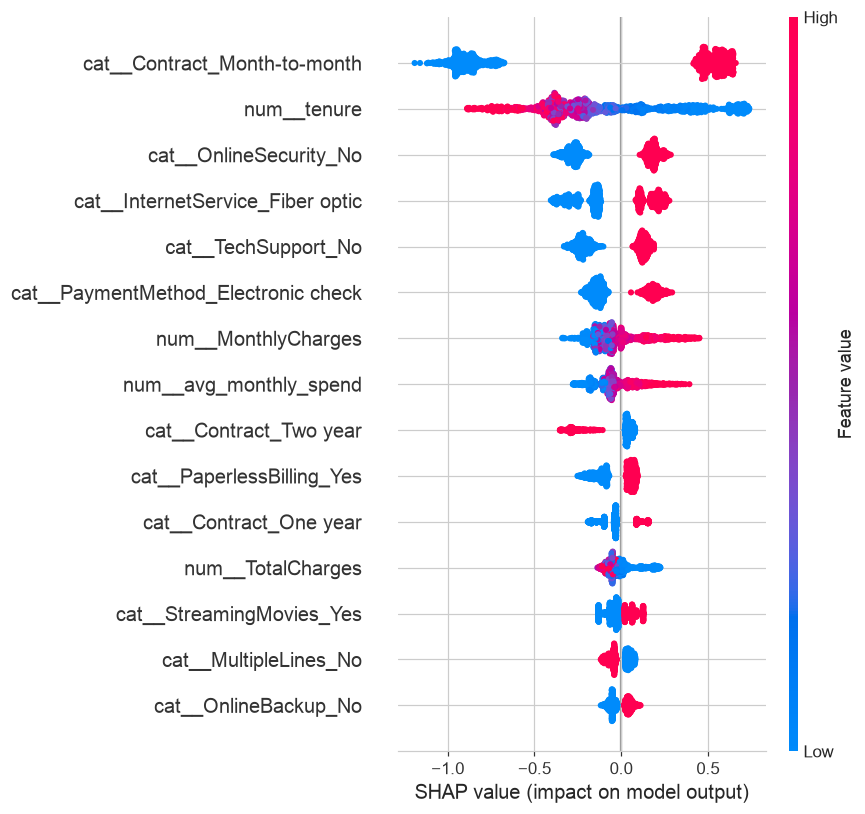

In [38]:
final_model = xgb_best
preprocessor = final_model.named_steps["pre"]
classifier = final_model.named_steps["clf"]

X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values, X_test_transformed, feature_names=feature_names,
    show=False, max_display=15,
)
plt.tight_layout()
plt.show()

Consistent with the mutual-information ranking in Section 5.7, contract
type, tenure, internet service type, and absence of tech support / online
security dominate the SHAP ranking -- the two independent methods agree,
which is a useful cross-check rather than a coincidence to note in passing.
Interpreting the summary plot directly:

- **Month-to-month contracts push predictions toward churn**; longer
  contracts push firmly the other way -- consistent with the survival curve
  in 5.4, where the hazard is front-loaded and month-to-month customers are
  the ones exposed to that early-tenure risk every renewal cycle.
- **Low tenure pushes toward churn**, again matching Section 5.4.
- **Fiber-optic internet without security/tech-support add-ons pushes toward
  churn** more than DSL does, consistent with the bundling effect in 5.6 --
  fiber customers without protective add-ons are a specific at-risk segment,
  not fiber customers generally.
- **Electronic check as payment method pushes toward churn**, consistent
  with 5.8.

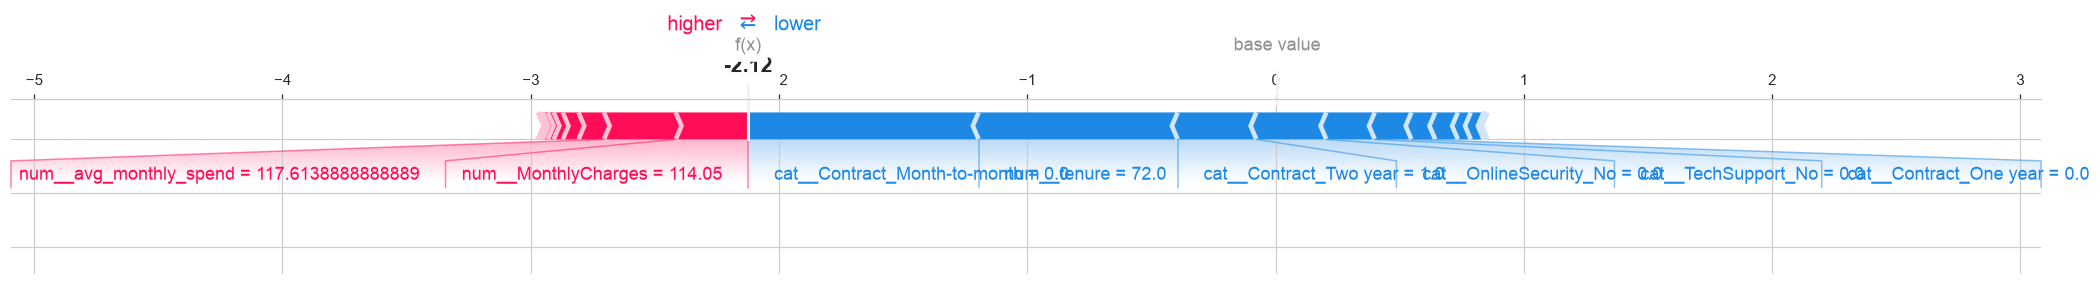

In [39]:
fig = shap.force_plot(
    explainer.expected_value, shap_values[0, :], X_test_transformed[0, :],
    feature_names=feature_names, matplotlib=True, show=False,
)
plt.tight_layout()
plt.show()

The force plot above shows one individual prediction decomposed into its
contributing features -- this is the granularity a customer-facing retention
team would actually need ("why is this specific customer flagged"), not
just the population-level summary.

### 11.1 From prediction to decision

A probability and a SHAP plot are not, on their own, something a retention
agent can act on in the middle of a call. The function below turns a single
prediction into the kind of card an agent-facing tool would actually
display -- risk tier, the specific drivers behind this customer's score,
and a recommended action tied to those drivers, not a generic one. This is
the same logic the Streamlit prototype (repository root: `app.py`) exposes
interactively.

In [40]:
def explain_customer(row_idx, model=xgb_best, X=X_test, explainer=explainer,
                      shap_values=shap_values, feature_names=feature_names):
    proba = model.predict_proba(X.iloc[[row_idx]])[0, 1]
    tier = assign_risk_tier(np.array([proba]))[0]

    row_shap = shap_values[row_idx]
    top_idx = np.argsort(-np.abs(row_shap))[:4]
    drivers = [
        (feature_names[i].split("__", 1)[-1], row_shap[i])
        for i in top_idx
    ]

    print(f"Customer index: {row_idx}")
    print(f"Churn probability: {proba:.1%}")
    print(f"Risk tier: {tier}")
    print("Top drivers (feature: SHAP contribution):")
    for name, val in drivers:
        direction = "increases risk" if val > 0 else "decreases risk"
        print(f"  {name}: {val:+.3f} ({direction})")

    if tier in ("Critical", "High"):
        recommendation = (
            "Prioritize for retention outreach. If Contract or PaymentMethod "
            "appears among the top drivers above, lead with a contract-term "
            "or payment-method offer rather than a generic discount."
        )
    elif tier == "Medium":
        recommendation = (
            "Monitor; consider inclusion in a lower-cost, broader retention "
            "campaign rather than individual outreach."
        )
    else:
        recommendation = "No action needed based on churn risk."
    print(f"Recommended action: {recommendation}")


for idx in [0, 7]:
    explain_customer(idx)
    print()

Customer index: 0
Churn probability: 10.7%
Risk tier: Low
Top drivers (feature: SHAP contribution):
  Contract_Month-to-month: -0.928 (decreases risk)
  tenure: -0.802 (decreases risk)
  Contract_Two year: -0.317 (decreases risk)
  MonthlyCharges: +0.292 (increases risk)
Recommended action: No action needed based on churn risk.

Customer index: 7
Churn probability: 28.3%
Risk tier: Low
Top drivers (feature: SHAP contribution):
  Contract_Month-to-month: +0.493 (increases risk)
  InternetService_Fiber optic: -0.340 (decreases risk)
  OnlineSecurity_No: -0.285 (decreases risk)
  TechSupport_No: -0.264 (decreases risk)
Recommended action: No action needed based on churn risk.



This is deliberately simple -- it reads directly off the already-computed
SHAP values and the risk tiers from 9.5, with no new modeling. The value is
in the framing, not the computation: it is the difference between an
analyst reading a summary plot and a retention agent seeing something they
can act on in the next five minutes.

## 12. Post-Deployment Monitoring Plan

A model that scores well on a held-out test set today degrades silently in
production for two distinct reasons, and each needs a different monitor:

**Data drift** -- the distribution of incoming customer records diverges from
the training distribution (e.g., a new pricing plan shifts `MonthlyCharges`,
or a new payment provider is added). Tracked via **Population Stability
Index (PSI)** per feature, computed weekly against the training-set
reference distribution. A PSI above 0.2 on any feature that ranked highly in
Section 11 (contract type, tenure, internet service, payment method)
triggers an investigation before it triggers a retrain -- drift in a
low-importance feature is lower priority than drift in a feature the model
actually relies on.

**Concept drift** -- the relationship between features and churn itself
changes (e.g., a competitor's pricing shifts what "expensive" means to
customers), which PSI cannot detect since the input distribution can stay
stable while the true relationship moves. Tracked via a **rolling
7/30-day recall and precision** computed once true churn outcomes are
observed and joined back to historical predictions, compared against the
test-set baseline in Section 9.1. A sustained drop is the trigger for
retraining, not a single bad week -- churn has natural noise and seasonality
(e.g., contract renewal cycles), and reacting to a single noisy week would
cause unnecessary retraining.

**Operational monitors**, independent of the two above:

- Prediction volume and class-rate drift (sudden change in the proportion of
  customers scored above the operating threshold -- often a pipeline or
  upstream data issue before it is a model issue).
- Latency and error rate of the scoring endpoint itself.
- Feature-level null-rate monitoring, since a silent upstream schema change
  (a field starting to arrive empty) would not be caught by PSI if the
  imputation strategy quietly absorbs it.

**Retraining cadence.** Scheduled quarterly retraining as a floor, with an
unscheduled retrain triggered immediately by either a PSI breach on a
top-ranked feature or a sustained recall/precision drop -- whichever comes
first. Every retrained candidate is evaluated against the current production
model on the same cost-sensitive metric from Section 9.3 before being
promoted (champion/challenger), not deployed automatically on training
completion. The full architecture for this -- Azure ML pipelines, model
registry, and the CI/CD wiring around it -- is detailed in the accompanying
architecture document rather than repeated here.

## 13. Assumptions, Limitations, and Next Steps

**Assumptions made explicit in this notebook:**

- The dataset is a single snapshot, not a longitudinal panel -- tenure at
  churn is inferred from a customer's current tenure at the time of the
  snapshot, not observed as an actual event stream. Section 5.4's survival
  curve should be read as directionally correct, not as a precise hazard
  estimate a true panel dataset would give.
- Cost figures in Section 9.3 (\$400 false negative, \$50 false positive)
  are stated assumptions for demonstrating cost-sensitive threshold
  selection, not derived from the dataset, which contains no cost fields.
- No campaign or marketing-spend data exists in this dataset. This matters
  for one thing explicitly requested for this exercise: a Marketing Mix
  Model was considered and is **not applicable here** -- MMM requires
  aggregated marketing spend by channel over time regressed against a
  revenue KPI, and this dataset is customer-level, cross-sectional, and
  contains no spend or campaign fields. Building an MMM on it would produce
  a fabricated result. The applicable analogue, covered as future work
  below, is uplift modeling.

**Limitations:**

- Single-snapshot data limits how confidently the survival analysis
  generalizes; a true panel dataset with observed churn dates would allow a
  full Cox proportional hazards model rather than a snapshot-based
  approximation.
- The three models cluster closely on ROC-AUC/PR-AUC, which caps how much
  further gain is available from model choice alone; the larger remaining
  lever is more likely additional features (support-ticket history, usage
  trend, competitor pricing exposure) than a different algorithm.

**Next steps:**

- **Uplift modeling** for retention-offer targeting: rather than only
  predicting who will churn, estimate the incremental effect of a specific
  retention action per customer (a T-learner or causal forest against
  historical campaign data, once such data exists) -- this is the correct
  tool for "where does retention spend move the needle," which a plain
  churn classifier does not answer on its own.
- A/B test the recommended model's retention-targeting policy against the
  current process before full rollout, rather than deploying on offline
  metrics alone.
- Revisit the cost matrix in Section 9.3 with actual Finance-provided
  acquisition-cost and offer-cost figures, and recompute the operating
  threshold once available.
- Extend monitoring (Section 12) with the Azure-native governance and
  audit-logging design covered in the architecture document, before this
  model is exposed to any automated retention decision.